In [208]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Spotify Metadata Analysis")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.instances", "7")
    .config("spark.executor.memory", "25g")
    .getOrCreate()
)


# Load Data

In [209]:
data_path = "/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet"
tracks = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/tracks.parquet")
available_markets = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/available_markets.parquet")
track_artists = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/track_artists.parquet")
artists = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/artists.parquet")
artist_genres = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/artist_genres.parquet")
artist_albums = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/artist_albums.parquet")
albums = spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/albums.parquet")
artist_images =spark.read.parquet("/expanse/lustre/projects/uci157/darenas/shared/spotify_clean_parquet/artist_images.parquet")



In [215]:
#count of all the tables we're interested for data exploration 
tracks.count() + available_markets.count() + track_artists.count() + artists.count() + artist_genres.count() + artist_albums.count() + albums.count()+ artist_images.count()


819022303

In [217]:
df = spark.read.parquet(data_path)
df.printSchema()


root
 |-- album_rowid: long (nullable = true)
 |-- width: long (nullable = true)
 |-- height: long (nullable = true)
 |-- url: string (nullable = true)



In [218]:
df.count()
#overall in the dataset, but will work with 819022303 out of 994832295

994832295

In [222]:
#DataFrames into a dictionary
tables = {
    "tracks": tracks,
    "available_markets": available_markets,
    "track_artists": track_artists,
    "artists": artists,
    "artist_genres": artist_genres,
    "artist_albums": artist_albums,
    "artist_images": artist_images,
    "albums": albums,
}

# Schema for Each Table

In [223]:
    for name, df in tables.items():
        print(f"\n{'='*20} {name.upper()} {'='*20}")
        df.printSchema()


==================== TRACKS ====================
root
 |-- rowid: long (nullable = true)
 |-- id: string (nullable = true)
 |-- fetched_at: long (nullable = true)
 |-- name: string (nullable = true)
 |-- preview_url: string (nullable = true)
 |-- album_rowid: long (nullable = true)
 |-- track_number: long (nullable = true)
 |-- external_id_isrc: string (nullable = true)
 |-- popularity: long (nullable = true)
 |-- available_markets_rowid: long (nullable = true)
 |-- disc_number: long (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- explicit: long (nullable = true)


==================== AVAILABLE_MARKETS ====================
root
 |-- rowid: long (nullable = true)
 |-- available_markets: string (nullable = true)


==================== TRACK_ARTISTS ====================
root
 |-- track_rowid: long (nullable = true)
 |-- artist_rowid: long (nullable = true)


==================== ARTISTS ====================
root
 |-- rowid: long (nullable = true)
 |-- id: string (nullabl

## NULL Counts for each Table

In [220]:
def null_counts(df):
    return df.select([F.count(F.col(c).isNull().cast("int")).alias(c) for c in df.columns])

In [224]:
from pyspark.sql import functions as F
for name, df in tables.items():
        print(f"\n{'='*20} {name.upper()} {'='*20}")
        null_counts(df).show()
        







==================== TRACKS ====================
+---------+---------+----------+---------+-----------+-----------+------------+----------------+----------+-----------------------+-----------+-----------+---------+
|    rowid|       id|fetched_at|     name|preview_url|album_rowid|track_number|external_id_isrc|popularity|available_markets_rowid|disc_number|duration_ms| explicit|
+---------+---------+----------+---------+-----------+-----------+------------+----------------+----------+-----------------------+-----------+-----------+---------+
|256039007|256039007| 256039007|256039007|  256039007|  256039007|   256039007|       256039007| 256039007|              256039007|  256039007|  256039007|256039007|
+---------+---------+----------+---------+-----------+-----------+------------+----------------+----------+-----------------------+-----------+-----------+---------+


==================== AVAILABLE_MARKETS ====================
+-----+-----------------+
|rowid|available_markets|
+-----

# Albums: distribution by album_type (categorical)

In [181]:
albums.groupBy("album_type").count().orderBy("count", ascending=False).show()

+-----------+--------+
| album_type|   count|
+-----------+--------+
|     single|46480163|
|      album|10647787|
|compilation| 1463032|
+-----------+--------+



# Basic Summary Statistics (Tracks: average duration and popularity)

In [182]:
from pyspark.sql import functions as F

tracks.select("duration_ms", "popularity").describe().show()

tracks.agg(
    F.avg("duration_ms").alias("avg_duration_ms"),
    F.min("duration_ms").alias("min_duration_ms"),
    F.max("duration_ms").alias("max_duration_ms"),
    F.avg("popularity").alias("avg_popularity")
    ).show()


+-------+------------------+------------------+
|summary|       duration_ms|        popularity|
+-------+------------------+------------------+
|  count|         256039007|         256039007|
|   mean|216552.69250035015| 1.386152923175491|
| stddev|176250.21654314408|5.0189119110232445|
|    min|                 0|                 0|
|    max|         356461000|               100|
+-------+------------------+------------------+

+------------------+---------------+---------------+-----------------+
|   avg_duration_ms|min_duration_ms|max_duration_ms|   avg_popularity|
+------------------+---------------+---------------+-----------------+
|216552.69250035015|              0|      356461000|1.386152923175491|
+------------------+---------------+---------------+-----------------+



In [205]:
# This cell checks for missing values in the 'popularity' column of the tracks DataFrame.
# count(*) = total rows
# count(popularity) = non-null popularity values
# null_popularity = number of missing (null) popularity values
tracks.select(
    F.count("*").alias("total_rows"),
    F.count("popularity").alias("non_null_popularity"),
    F.sum(F.col("popularity").isNull().cast("int")).alias("null_popularity")
).show()



+----------+-------------------+---------------+
|total_rows|non_null_popularity|null_popularity|
+----------+-------------------+---------------+
| 256039007|          256039007|              0|
+----------+-------------------+---------------+



## Artist Images

In [213]:
artist_images.groupBy("artist_rowid").count().show() # how many images an artist has

+------------+-----+
|artist_rowid|count|
+------------+-----+
|          26|    3|
|        1677|    3|
|        1950|    3|
|        2214|    3|
|        2250|    3|
|        2529|    3|
|        4823|    3|
|        4894|    3|
|        5385|    3|
|        5409|    3|
|        5556|    3|
|        7225|    3|
|        7279|    3|
|        7747|    3|
|        8075|    3|
|        8440|    3|
|        8484|    3|
|        9233|    3|
|        9458|    3|
|        9715|    3|
+------------+-----+
only showing top 20 rows



This table shows a sample of the number of images each artist has. From this, we can see that each artist has exactly 3 images, likely for different screen size resolutions (phone, tablet, computer).


In [214]:
artist_images.groupBy("width").count().orderBy("width").show() #image resolution for artist images

+-----+-------+
|width|  count|
+-----+-------+
|   59|      2|
|   62|      4|
|   63|   1000|
|   64|5697026|
|  160|3219532|
|  197|      1|
|  198|     45|
|  199|   1076|
|  200|  23799|
|  201|      5|
|  202|      1|
|  203|      4|
|  204|      4|
|  205|      2|
|  207|      3|
|  208|      2|
|  209|      3|
|  210|      5|
|  212|      5|
|  213|      2|
+-----+-------+
only showing top 20 rows



This table shows a sample of how many images exist for each width size. However the uncommon width values tell us that these are not raw pixel resolutions and the data is stored in a different unit of measure such as transformed size.


# DATA Visualizations

In [184]:
 # See Top Artists by Popularity

In [185]:

# Show top 10 artists by popularity
artists.select("name", "popularity", "followers_total") \
    .orderBy("popularity", ascending=False) \
    .show(10, truncate=False)


+--------------+----------+---------------+
|name          |popularity|followers_total|
+--------------+----------+---------------+
|Bad Bunny     |100       |93195263       |
|Taylor Swift  |98        |135140074      |
|Drake         |98        |97342434       |
|Kendrick Lamar|97        |39723389       |
|The Weeknd    |97        |102484717      |
|Playboi Carti |96        |13916270       |
|Bruno Mars    |95        |70128274       |
|Billie Eilish |95        |109602603      |
|Lady Gaga     |94        |36284092       |
|SZA           |94        |28531682       |
+--------------+----------+---------------+
only showing top 10 rows



In [186]:
import matplotlib.pyplot as plt

# ============================================================
# Top 10 Artists by Popularity
# ============================================================
top_artists = (
    artists
    .select("name", "popularity")
    .orderBy(F.col("popularity").desc())
    .limit(10)
)

top_artists_pd = top_artists.toPandas()


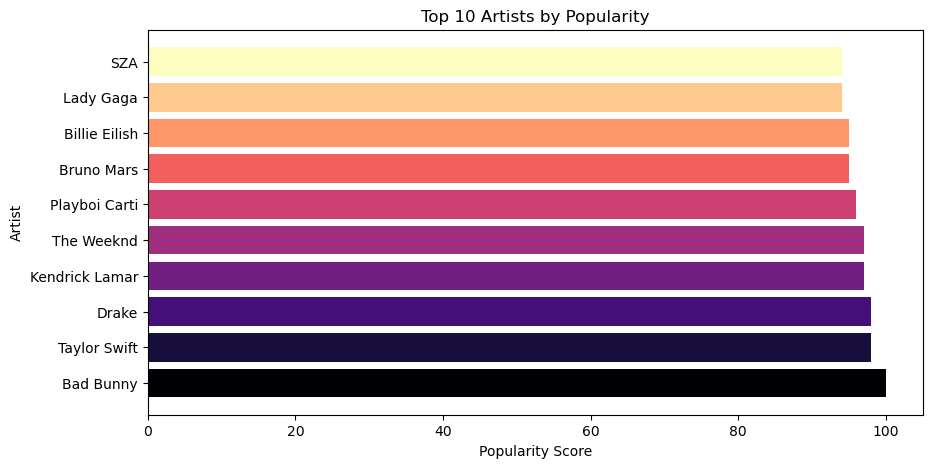

In [187]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
colors = plt.cm.magma(np.linspace(0, 1, len(top_artists_pd)))
plt.barh(top_artists_pd["name"], top_artists_pd["popularity"], color=colors)
plt.xlabel("Popularity Score")
plt.ylabel("Artist")
plt.title("Top 10 Artists by Popularity")
#plt.gca().invert_yaxis()
plt.show()

This bar chart displays the top 10 artists by popularity score. Each bar represents an artist, with longer bars indicating higher popularity. The chart highlights that these artists are among the most popular in the dataset, with scores clustered near the upper end of the scale. This visualization makes it easy to identify the leading artists in terms of popularity.




In [188]:

# Join artists and genres on rowid
artists_with_genre = artists.join(artist_genres, artists.rowid == artist_genres.artist_rowid, "inner")


In [189]:
top_artists_with_genre = (
    artists_with_genre
    .select("name", "popularity", "genre")
    .orderBy(F.col("popularity").desc())
    .limit(10)
)
top_artists_with_genre_pd = top_artists_with_genre.toPandas()

In [190]:
# Get top 10 artists by popularity
top_artists = (
    artists
    .select("rowid", "name", "popularity")
    .orderBy(F.col("popularity").desc())
    .limit(10)
)

# Left join with genres (so artists without genre are kept)
top_artists_with_genre = top_artists.join(
    artist_genres, top_artists.rowid == artist_genres.artist_rowid, "left"
)

top_artists_with_genre_pd = top_artists_with_genre.select("name", "popularity", "genre").toPandas()

In [191]:
top_artists_with_genre_pd["genre"] = top_artists_with_genre_pd["genre"].fillna("Unknown")

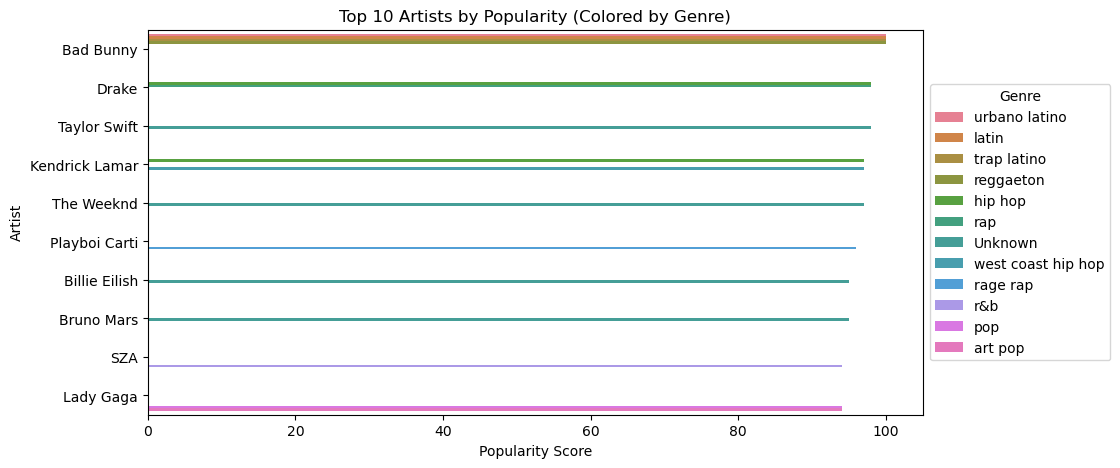

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax =sns.barplot(
    y=top_artists_with_genre_pd["name"],
    x=top_artists_with_genre_pd["popularity"],
    hue=top_artists_with_genre_pd["genre"] 

)
plt.xlabel("Popularity Score")
plt.ylabel("Artist")
plt.title("Top 10 Artists by Popularity (Colored by Genre)")
#plt.gca().invert_yaxis()
plt.legend(title="Genre",loc='center left', bbox_to_anchor=(1, 0.5))


This bar chart displays the top 10 artists by popularity, with each bar colored according to the artist’s primary genre. The visualization highlights both the most popular artists and the diversity of genres represented among the top performers. It shows that top artists span a range of genres, not just one musical style.


In [193]:
pop_counts =(tracks.groupBy("popularity").count().orderBy("popularity"))

#convert the aggregated result to pandas for plotting
pop_pd = pop_counts.toPandas()

In [194]:

# Show the top 10 tracks by popularity, including their names
tracks.select("name", "popularity").orderBy(F.col("popularity").desc()).show(10, truncate=False)


+---------------------------------------+----------+
|name                                   |popularity|
+---------------------------------------+----------+
|Die With A Smile                       |100       |
|BIRDS OF A FEATHER                     |98        |
|DtMF                                   |98        |
|Clean Baby Sleep White Noise (Loopable)|97        |
|That’s So True                         |96        |
|Not Like Us                            |96        |
|BAILE INoLVIDABLE                      |96        |
|WILDFLOWER                             |95        |
|Sailor Song                            |95        |
|All The Stars (with SZA)               |95        |
+---------------------------------------+----------+
only showing top 10 rows



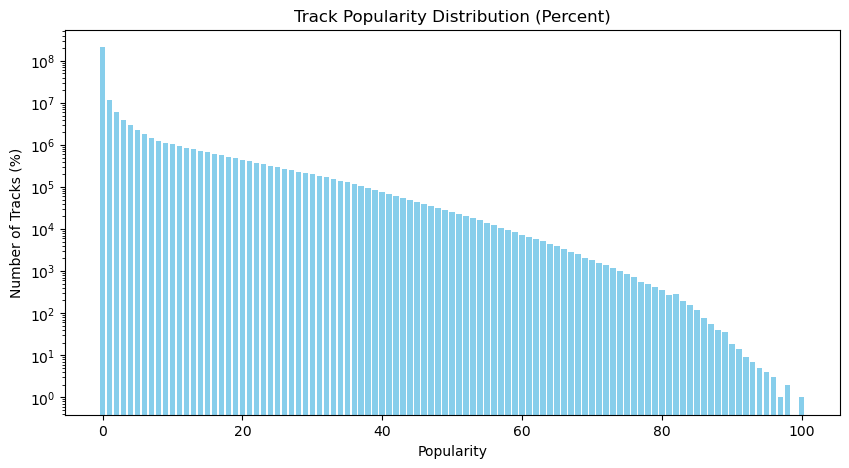

In [195]:
plt.figure(figsize=(10, 5))
plt.bar(pop_pd["popularity"], pop_pd["count"], color="skyblue")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks (%)")
plt.title("Track Popularity Distribution (Percent)")
plt.yscale("log")

plt.show()


The barplot above shows how many tracks have each given popularity value. As seen in the image, not many tracks are successful enough to be called a hit. For example, the bar at "popularity = 0" represents about 2 million tracks, meaning 2 million tracks have a popularity score of zero. In contrast, the bar at "popularity = 100" represents only a handful of tracks, indicating that very few tracks reach maximum popularity.
Viewing the barplot, we gain insight that anything below a popularity score of 70 is not really considered a hit song from our viewpoint. The right side of the plot contains only small bars, showing that very few tracks are truly successful. This extreme right-skewed distribution is typical in large music catalogs, where most tracks receive little attention and only a select few become highly popular.

In [196]:
sample_df = (tracks.select("duration_ms","popularity")
             .where(F.col("duration_ms").isNotNull())
             .sample(fraction=.001,seed=42))
sample_pd = sample_df.toPandas()        

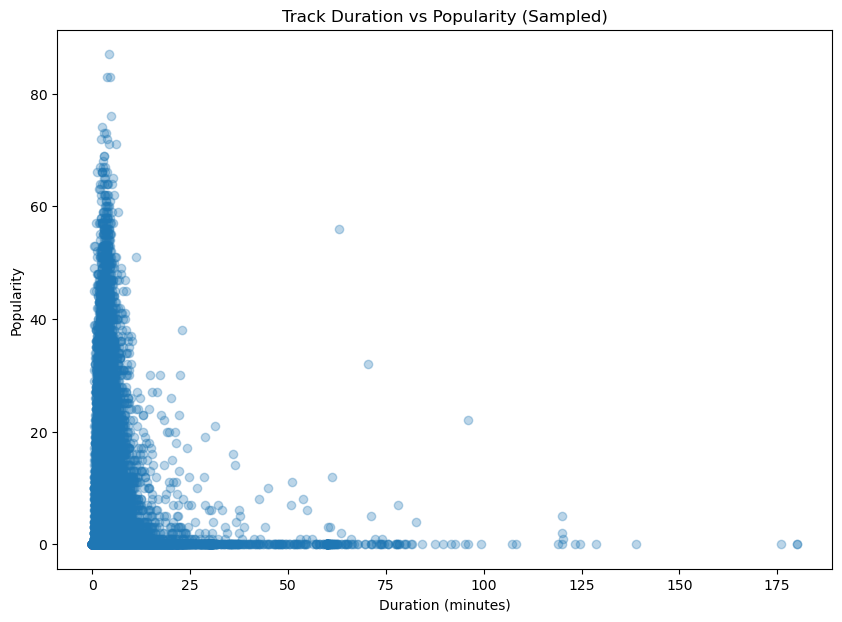

In [197]:
plt.figure(figsize = (10,7))
plt.scatter(sample_pd['duration_ms']/60000, sample_pd["popularity"], alpha = .3)
plt.xlabel("Duration (minutes)")
plt.ylabel("Popularity")
plt.title("Track Duration vs Popularity (Sampled)")
plt.show()


This scatter plot shows the relationship between track duration (in minutes) and popularity for a random sample of tracks. Each point represents a track, with its duration on the x-axis and its popularity score on the y-axis.
Insights:

Most tracks cluster between about 2 and 5 minutes in duration, and these tracks span a wide range of popularity scores.
There is no strong linear relationship between duration and popularity; tracks of all lengths can be unpopular, but highly popular tracks are almost always short.
Very long tracks (over 30 minutes) are rare and tend to have low popularity, suggesting that extended tracks (such as podcasts or experimental music) are less likely to be hits.
The plot confirms that mainstream, popular tracks are typically of standard song length, while outliers in duration are not widely played.

This visualization helps illustrate that track length alone does not determine popularity, but most successful tracks fall within a typical duration range.

In [204]:
bts = artists[artists['name'] == "BTS"].select(['name', 'popularity', 'followers_total'])

bts.show()


+----+----------+---------------+
|name|popularity|followers_total|
+----+----------+---------------+
| BTS|         2|           5855|
| BTS|         0|           3656|
| BTS|        87|       78420458|
| BTS|         3|          19206|
| BTS|         0|            221|
| BTS|         2|           2238|
+----+----------+---------------+



In [201]:
weekend = artists[artists['name'] == "Weekend"].select(['name', 'popularity', 'followers_total'])
weekend.show()

+-------+----------+---------------+
|   name|popularity|followers_total|
+-------+----------+---------------+
|Weekend|         2|              0|
|Weekend|        15|           2496|
|Weekend|        14|           5889|
|Weekend|        48|          28774|
|Weekend|        37|            111|
|Weekend|         0|              0|
|Weekend|        35|          59012|
|Weekend|         0|              6|
|Weekend|        10|            105|
|Weekend|         0|             27|
|Weekend|        12|             44|
|Weekend|         0|             54|
|Weekend|         0|             81|
|Weekend|        27|           1192|
|Weekend|         0|              1|
|Weekend|         0|              1|
|Weekend|         0|              4|
|Weekend|         0|              0|
|Weekend|         0|              0|
|Weekend|         0|              1|
+-------+----------+---------------+
only showing top 20 rows



### Exploratory Data Analysis Note:
While investigating the dataset, We wanted to understand why BTS isn't appearing in the top 10 artists by followers or popularity. Upon inspection, We discovered multiple duplicate entries for BTS, each with different values for popularity and followers. This issue is not unique to BTS; other artists, such as "Weekend," also have several duplicate rows with varying metrics.
For now, We are focusing on exploratory data analysis and will address data cleaning and deduplication in a later step.

# Data Cleaning 

In [ ]:
# removing duplicates- keeping the highest followers with its corresponding pop score